In [17]:
import pandas as pd 
import numpy as np
import re 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

import keras 
from keras import layers
from keras.utils import to_categorical

#Task 1 and 2: Data understanding and preprocessing
print("Loading and cleaning data...")
df = pd.read_csv('customer_support_text_classification.csv')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text
df['clean_text'] = df['customer_message'].apply(clean_text)

X = df['clean_text'].values
y = df['sentiment_label'].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)



Loading and cleaning data...


In [18]:
#Task 3 and 4: Text vectorization and baseline model training
print("\n--- Training Baseline Model ---")
#Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#Training Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
#Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Baseline Report:\n", classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))




--- Training Baseline Model ---
Baseline Accuracy: 1.0000
Baseline Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300




--- Training Sequence Model (Keras 3 LSTM) ---
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3433 - loss: 1.0955 - val_accuracy: 0.3600 - val_loss: 1.0618
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6467 - loss: 0.6320 - val_accuracy: 0.6367 - val_loss: 0.4792
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6658 - loss: 0.4665 - val_accuracy: 0.6367 - val_loss: 0.4690
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6742 - loss: 0.4580 - val_accuracy: 0.7100 - val_loss: 0.4560
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6642 - loss: 0.4564 - val_accuracy: 0.7100 - val_loss: 0.4549


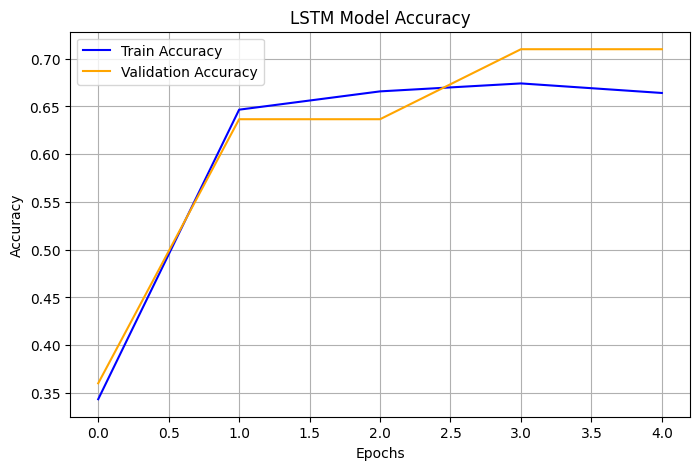

Saved: results/model_evaluation.png

LSTM Test Accuracy: 0.7100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Saved: results/sample_predictions.txt


In [21]:
#Task 5: Sequence modeling with Keras 3 LSTM
print("\n--- Training Sequence Model (Keras 3 LSTM) ---")
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

vocab_size = 5000
max_sequence_length = 30

vectorize_layer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode='int', 
    output_sequence_length=max_sequence_length
)
vectorize_layer.adapt(X_train)

X_train_seq = vectorize_layer(X_train)
X_test_seq = vectorize_layer(X_test)

model = keras.Sequential([
    #Converting integers to dense vectors of 32 size.
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    #Sequence layer LSTM to capture context.
    layers.LSTM(32),
    #Output layer 
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


#Training model directly on raw text data
history = model.fit(
    X_train_seq, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_seq, y_test_cat)
)
#Saving the evaluation model
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('results/model_evaluation.png')
plt.show()
plt.close()
print("Saved: results/model_evaluation.png")
loss, lstm_acc = model.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f"\nLSTM Test Accuracy: {lstm_acc:.4f}")
#Saving Sample predictions
sample_texts = X_test[:10]
sample_seqs = vectorize_layer(sample_texts)

lstm_predictions = model.predict(sample_seqs)
predicted_classes = label_encoder.inverse_transform(np.argmax(lstm_predictions, axis=1))
actual_classes = label_encoder.inverse_transform(y_test[:10])

with open('results/sample_predictions.txt', 'w') as f:
    f.write("LSTM MODEL SAMPLE PREDICTIONS\n")
    f.write("="*50 + "\n\n")
    for text, actual, pred in zip(sample_texts, actual_classes, predicted_classes):
        f.write(f"Customer Message: '{text.strip()}'\n")
        f.write(f"Actual Sentiment:    {actual.upper()}\n")
        f.write(f"Predicted Sentiment: {pred.upper()}\n")
        f.write("-" * 50 + "\n")
        
print("Saved: results/sample_predictions.txt")
